# China Township Boundary

In this notebook, we work with **township-level administrative boundaries** in China. The focus is on boundaries published in 2019 on wordpress : [Revolutionary GIS](https://revolutionarygis.wordpress.com/2019/11/14/china-township-shapefile-data/)


- **Village-level boundaries:** Currently, there is no available official data for village boundaries in China. Most open datasets provide information only at the **township level**.  

- **Township boundaries:** These are also available from more official sources:  
**[National Geospatial Data Platform (geodata.cn)](https://www.geodata.cn/datapplication/OrderStepList.html?dataguid=26681012531842)** and **[MalaGIS](https://malagis.com/gis-data-province-city-county-town-village-vector-data.html)** provide administrative boundaries at the township level. Some datasets may require Chinese registrationand not all are freely downloadable. They might be more accurate and up-to-date.

## Setup 

In [2]:
!pip install rarfile
!pip install pypinyin

In [3]:
import os
import requests
import rarfile
import geopandas as gpd
import matplotlib.pyplot as plt
from pypinyin import lazy_pinyin
import folium

## Cleaning 

Download the rar folder *ChinaTownships* on [Mega](https://mega.nz/file/nExURKiA#xeQjuEHAss2EaUDoFQ8jS4KZ7XSs_dbpiCLSW2tfOrw)

In [2]:
townships = gdp.read_file("../../data/raw_data/ChinaTownships/xiangzhen.shp")

In [62]:
townships.head()

,geom,geometry,省,Province_pinyin,市,City_pinyin,县,County_pinyin,乡,Township_pinyin
0,"SRID=4326;MULTIPOLYGON(((113.58654372861 32.4311292947818,113.594274363953 32.4242334016731,113....","POLYGON ((113.58 32.433, 113.59 32.427, 113.59 32.425, 113.59 32.42, 113.59 32.419, 113.59 32.41...",河南省,he nan sheng,南阳市,nan yang shi,桐柏县,tong bai xian,吴城镇,wu cheng zhen
1,"SRID=4326;MULTIPOLYGON(((114.655030581138 33.6222344912964,114.655374741289 33.6180360814594,114...","POLYGON ((114.65 33.624, 114.65 33.62, 114.65 33.615, 114.65 33.606, 114.65 33.606, 114.65 33.60...",河南省,he nan sheng,周口市,zhou kou shi,川汇区,chuan hui qu,陈州回族街道,chen zhou hui zu jie dao
2,"SRID=4326;MULTIPOLYGON(((115.026098835668 34.2874010451502,115.024136477233 34.286028726462,115....","POLYGON ((115.02 34.289, 115.02 34.287, 115.02 34.284, 115.01 34.279, 115.01 34.279, 115 34.278,...",河南省,he nan sheng,商丘市,shang qiu shi,睢县,sui xian,孙聚寨乡,sun ju zhai xiang
3,"SRID=4326;MULTIPOLYGON(((112.227729849696 32.682635104769,112.221047893899 32.6827072876023,112....","POLYGON ((112.22 32.685, 112.22 32.685, 112.21 32.685, 112.21 32.686, 112.19 32.69, 112.19 32.69...",河南省,he nan sheng,南阳市,nan yang shi,邓州市,deng zhou shi,白牛镇,bai niu zhen
4,"SRID=4326;MULTIPOLYGON(((114.646057216599 33.6117613672786,114.641497814051 33.6035283449855,114...","POLYGON ((114.64 33.613, 114.64 33.605, 114.64 33.604, 114.63 33.604, 114.63 33.603, 114.63 33.6...",河南省,he nan sheng,周口市,zhou kou shi,川汇区,chuan hui qu,荷花街道,he hua jie dao


In [63]:
townships.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 43655 entries, 0 to 43654
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   geom             43655 non-null  object  
 1   geometry         43655 non-null  geometry
 2   省                43655 non-null  object  
 3   Province_pinyin  43655 non-null  object  
 4   市                43655 non-null  object  
 5   City_pinyin      43655 non-null  object  
 6   县                43655 non-null  object  
 7   County_pinyin    43655 non-null  object  
 8   乡                43655 non-null  object  
 9   Township_pinyin  43655 non-null  object  
dtypes: geometry(1), object(9)
memory usage: 3.3+ MB


In [ ]:
def add_pinyin_columns(gdf):
    """
    Add pinyin transliterations for province, city, county, township
    """
    mapping = {
        "省": "Province",
        "市": "City",
        "县": "County",
        "乡": "Township"
    }
    
    for col, eng_name in mapping.items():
        gdf[f"{eng_name}_pinyin"] = gdf[col].apply(
            lambda x: " ".join(lazy_pinyin(x)) # add space 
        )
    
    # Reorder columns
    new_order = ["geom", "geometry"]
    for col, eng_name in mapping.items():
        new_order.extend([col, f"{eng_name}_pinyin"])
    
    new_order = [c for c in new_order if c in gdf.columns] + \
                [c for c in gdf.columns if c not in new_order]
    
    return gdf[new_order]

In [64]:
townships= add_pinyin_columns(townships)

townships.head()

,geom,geometry,省,Province_pinyin,市,City_pinyin,县,County_pinyin,乡,Township_pinyin
0,"SRID=4326;MULTIPOLYGON(((113.58654372861 32.4311292947818,113.594274363953 32.4242334016731,113....","POLYGON ((113.58 32.433, 113.59 32.427, 113.59 32.425, 113.59 32.42, 113.59 32.419, 113.59 32.41...",河南省,he nan sheng,南阳市,nan yang shi,桐柏县,tong bai xian,吴城镇,wu cheng zhen
1,"SRID=4326;MULTIPOLYGON(((114.655030581138 33.6222344912964,114.655374741289 33.6180360814594,114...","POLYGON ((114.65 33.624, 114.65 33.62, 114.65 33.615, 114.65 33.606, 114.65 33.606, 114.65 33.60...",河南省,he nan sheng,周口市,zhou kou shi,川汇区,chuan hui qu,陈州回族街道,chen zhou hui zu jie dao
2,"SRID=4326;MULTIPOLYGON(((115.026098835668 34.2874010451502,115.024136477233 34.286028726462,115....","POLYGON ((115.02 34.289, 115.02 34.287, 115.02 34.284, 115.01 34.279, 115.01 34.279, 115 34.278,...",河南省,he nan sheng,商丘市,shang qiu shi,睢县,sui xian,孙聚寨乡,sun ju zhai xiang
3,"SRID=4326;MULTIPOLYGON(((112.227729849696 32.682635104769,112.221047893899 32.6827072876023,112....","POLYGON ((112.22 32.685, 112.22 32.685, 112.21 32.685, 112.21 32.686, 112.19 32.69, 112.19 32.69...",河南省,he nan sheng,南阳市,nan yang shi,邓州市,deng zhou shi,白牛镇,bai niu zhen
4,"SRID=4326;MULTIPOLYGON(((114.646057216599 33.6117613672786,114.641497814051 33.6035283449855,114...","POLYGON ((114.64 33.613, 114.64 33.605, 114.64 33.604, 114.63 33.604, 114.63 33.603, 114.63 33.6...",河南省,he nan sheng,周口市,zhou kou shi,川汇区,chuan hui qu,荷花街道,he hua jie dao


In [68]:
townships.to_file("../../data/data_processed/mapdata/chinatownships.geojson", driver="GeoJSON")

## Exploratory 

In [65]:
# vizualization for chec

first_geom = townships.iloc[0:1]   
m = folium.Map(location=[first_geom.geometry.centroid.y.values[0],
                         first_geom.geometry.centroid.x.values[0]], zoom_start=10)

folium.GeoJson(first_geom).add_to(m)

m


C:\Users\charl\AppData\Local\Temp\ipykernel_10864\3134879463.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  m = folium.Map(location=[first_geom.geometry.centroid.y.values[0],
C:\Users\charl\AppData\Local\Temp\ipykernel_10864\3134879463.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  first_geom.geometry.centroid.x.values[0]], zoom_start=10)


In [5]:
gadam = gpd.read_file(r"C:\Users\charl\solar-data-china\data\data_processed\mapdata\gadm41_CHN_3_processed.json")

In [42]:
gadam.head()

,GID_3,GID_0,Country,GID_1,Province,Province_hanzi,GID_2,Prefecture,Prefecture_hanzi,County,County_pinyin,County_hanzi,County_type_pinyin,County_type_eng,CC_3,HASC_3,geometry
0,CHN.1.1.1_1,CHN,China,CHN.1_1,Anhui,安徽|安徽,CHN.1.1_1,Anqing,安庆市,Anqing,None,None,Xiànjíshì,CountyCity,None,None,"MULTIPOLYGON (((117.01 30.496, 117.01 30.499, 117 30.511, 116.98 30.519, 116.97 30.532, 116.96 3..."
1,CHN.1.1.2_1,CHN,China,CHN.1_1,Anhui,安徽|安徽,CHN.1.1_1,Anqing,安庆市,Huaining,Huáiníng,怀宁县,Xiàn,County,None,None,"MULTIPOLYGON (((117.04 30.665, 117.04 30.657, 117.04 30.636, 117.04 30.633, 117.05 30.628, 117.0..."
2,CHN.1.1.3_1,CHN,China,CHN.1_1,Anhui,安徽|安徽,CHN.1.1_1,Anqing,安庆市,Qianshan,Qiánshān,潜山县,Xiàn,County,None,None,"MULTIPOLYGON (((116.76 30.824, 116.76 30.82, 116.75 30.822, 116.75 30.822, 116.75 30.809, 116.75..."
3,CHN.1.1.4_1,CHN,China,CHN.1_1,Anhui,安徽|安徽,CHN.1.1_1,Anqing,安庆市,Susong,Sùsōng,宿松县,Xiàn,County,None,None,"MULTIPOLYGON (((115.94 30.427, 115.95 30.426, 115.98 30.43, 116 30.425, 116.02 30.418, 116.03 30..."
4,CHN.1.1.5_1,CHN,China,CHN.1_1,Anhui,安徽|安徽,CHN.1.1_1,Anqing,安庆市,Taihu,Tàihú,太湖县,Xiàn,County,None,None,"MULTIPOLYGON (((116.47 30.457, 116.47 30.451, 116.47 30.444, 116.48 30.434, 116.48 30.418, 116.4..."


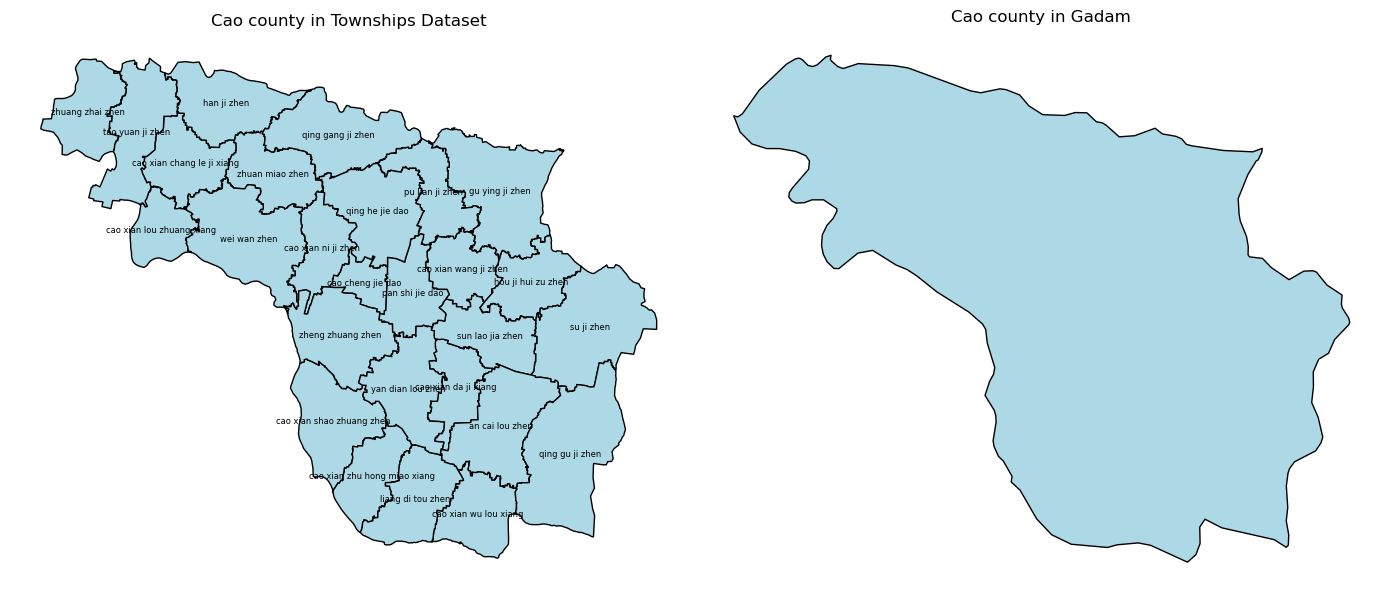

In [50]:
county_townships = townships[townships["County_pinyin"] == "cao xian"]

county_gadam = gadam[gadam["County"] == "Cao"]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

county_townships.plot(ax=axes[0], color="lightblue", edgecolor="black")
axes[0].set_title(f"Cao county in Townships Dataset")
axes[0].axis("off")

for idx, row in county_townships.iterrows():
    centroid = row.geometry.centroid
    axes[0].text(
        centroid.x, centroid.y,
        row["Township_pinyin"],
        fontsize=6, ha="center", va="center", color="black"
    )


county_gadam.plot(ax=axes[1], color="lightblue", edgecolor="black")
axes[1].set_title("Cao county in Gadam")
axes[1].axis("off")

plt.tight_layout()
plt.show()


In [67]:
m = folium.Map(location=[county_gadam.geometry.centroid.y.values[0],
                         county_gadam.geometry.centroid.x.values[0]], zoom_start=10)

folium.GeoJson(county_gadam).add_to(m)

m

C:\Users\charl\AppData\Local\Temp\ipykernel_10864\3498368276.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  m = folium.Map(location=[county_gadam.geometry.centroid.y.values[0],
C:\Users\charl\AppData\Local\Temp\ipykernel_10864\3498368276.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  county_gadam.geometry.centroid.x.values[0]], zoom_start=10)
